# Stock market analysis using data from the Yahoo-Finance Web API

## Libraries and settings

In [1]:
# Libraries
import os
import ta
import fnmatch
import pandas as pd
import yfinance as yf
from datetime import datetime
import matplotlib.pyplot as plt

# Define settings for graphics
# plt.style.use('dark_background')

# Settings
import warnings
warnings.filterwarnings("ignore")

# Current working directory
print(os.getcwd())

/workspaces/data_ingestion/04_Yahoo_Finance_WebAPI


## Get data
List of stock market symbols: https://finance.yahoo.com/lookup

In [2]:
# Retrieve the Microsoft stock data from Yahoo finance
today = datetime.now().strftime("%Y-%m-%d")
print('Today is:', today)

data = yf.download('MSFT', start="2022-01-01", end=today, progress=False)
data.tail()

Today is: 2026-08-20


Price,Close,High,Low,Open,Volume
Ticker,MSFT,MSFT,MSFT,MSFT,MSFT
Date,,,,,
2026-08-13,496.880005,501.339996,493.010010,493.269989,23039000
2026-08-14,495.399994,500.010010,493.920013,496.359985,16217600
2026-08-17,480.350006,492.660004,478.410004,490.140015,29635800
2026-08-18,481.630005,484.269989,477.149994,481.540009,24087600
2026-08-19,484.309998,489.299988,479.359985,480.070007,19885600


## Calculate techniqual indicators

In [3]:
# Function to compute Bollinger Bands
def BBANDS(data, n):
    MA = data.Close.rolling(window=n).mean()
    SD = data.Close.rolling(window=n).std()
    data['MiddleBand'] = MA
    data['UpperBand'] = MA + (2 * SD)
    data['LowerBand'] = MA - (2 * SD)
    return data


# Compute the Bollinger Bands for Google using the 50-day Moving average
BBANDS = BBANDS(data, 50)
BBANDS

Price,Close,High,Low,Open,Volume,MiddleBand,UpperBand,LowerBand
Ticker,MSFT,MSFT,MSFT,MSFT,MSFT,,,
Date,,,,,,,,
2022-01-03,322.462372,325.593074,317.674804,323.040354,28865100,NaN,NaN,NaN
2022-01-04,316.933105,322.895893,314.149174,322.539450,32674300,NaN,NaN,NaN
2022-01-05,304.766632,314.100943,304.381321,313.898631,40054300,NaN,NaN,NaN
2022-01-06,302.358398,307.001478,300.056114,301.655184,39646100,NaN,NaN,NaN
2022-01-07,302.512604,304.882297,298.707584,302.618552,32720000,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...
2026-08-13,496.880005,501.339996,493.010010,493.269989,23039000,411.414398,500.674206,322.154590
2026-08-14,495.399994,500.010010,493.920013,496.359985,16217600,412.775598,505.051537,320.499658


## Plot data and techniqual indicators

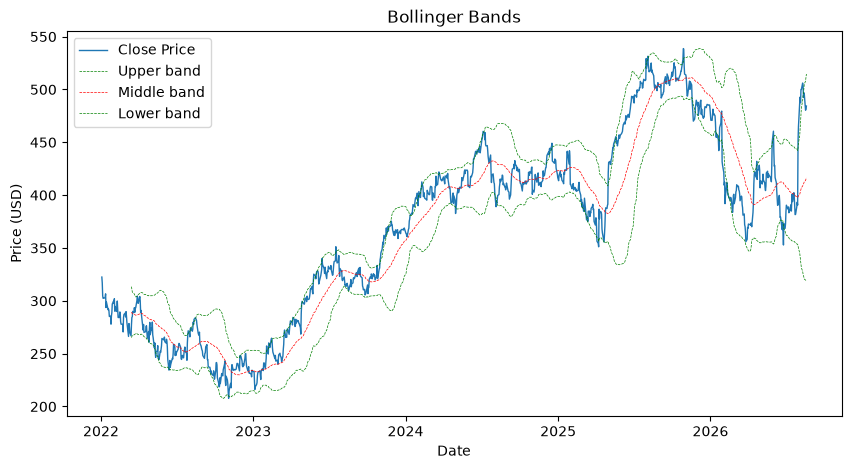

In [4]:
# Create the plot
plt.figure(figsize=(10, 5))

# Set the title and axis labels
plt.title('Bollinger Bands')
plt.xlabel('Date')
plt.ylabel('Price (USD)')

plt.plot(BBANDS.Close, lw=1.0, label='Close Price')
plt.plot(data['UpperBand'], 'g--', lw=0.5, label='Upper band')
plt.plot(data['MiddleBand'], 'r--', lw=0.5, label='Middle band')
plt.plot(data['LowerBand'], 'g--', lw=0.5, label='Lower band')

# Add a legend to the axis
plt.legend()

plt.show()

### Jupyter notebook --footer info-- (please always provide this at the end of each notebook)

In [5]:
import os
import platform
import socket
from platform import python_version
from datetime import datetime

print('-----------------------------------')
print(os.name.upper())
print(platform.system(), '|', platform.release())
print('Datetime:', datetime.now().strftime("%Y-%m-%d %H:%M:%S"))
print('Python Version:', python_version())
print('-----------------------------------')

-----------------------------------
POSIX
Linux | 6.8.0-1052-azure
Datetime: 2026-08-20 06:01:23
Python Version: 3.12.13
-----------------------------------
